In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

matplotlib.style.use(os.path.join("/shared_home/henachman/.matplotlib/stylelib", "HNCustomMono.mplstyle"))

# Import
import camb


In [23]:
# Maximum multipole of the spectra, which is set by the maps resolution
lmax = 5000

# Set up a new set of parameters for CAMB
# The defaults give one massive neutrino and helium set using BBN consistency
cosmo_params = dict(
    H0=67.5, # Hubble constant today, in km/s/Mpc. Sets the present expansion rate.
    ombh2=0.022, # Physical baryon density, controls the baryon content: protons, nuclei, electrons.
    omch2=0.122, # Physical cold dark matter density, controls the CDM abundance.
    mnu=0.06, # Sum of neutrino masses, in eV.
    omk=0.0, # Curvature density, 0.0 means a spatially flat Universe.
    tau=0.06, # Optical depth to reionization.
    As=2.0e-9, # Amplitude of the primordial scalar power spectrum, defined at a pivot scale. Sets the overall amplitude of initial perturbations.
    ns=0.965, # Scalar spectral index. Controls the tilt of the primordial scalar spectrum; ns < 1 means slightly more power on large scales than small scales.
    halofit_version="mead", # Choice of nonlinear matter power spectrum correction. "mead" refers to the Mead/HMCode-style nonlinear prescription.
    lmax=lmax,
)

def get_cosmo(cosmo_params, file_tag="fiducial"):
    pars = camb.set_params(**cosmo_params, WantTransfer=True)
    # print(pars)
    pars.set_for_lmax(lmax, lens_potential_accuracy=2)

    # Compute results for these parameters
    results = camb.get_results(pars)
    cls = results.get_total_cls(lmax=lmax, CMB_unit="muK")


    results.calc_power_spectra()
    results.calc_transfers(pars)

    mp_spec = results.get_matter_power_spectrum()
    # save the matter power spectrum as a dat file\
    np.savetxt(f"CAMB_Pk_{file_tag}.dat", np.column_stack([mp_spec[0], mp_spec[2][0]]))

    # CAMB returns columns TT, EE, BB, TE. Store them with ell as the first column.
    # This file will be used by later notebooks.
    ell = np.arange(lmax + 1)
    np.savetxt(f"CAMB_scalCls_{file_tag}.dat", np.column_stack([ell, cls]))

    print(f"Saved CAMB {file_tag} products.")

In [24]:
get_cosmo(cosmo_params)
cosmo_params["mnu"] = 0.006
get_cosmo(cosmo_params, "lightNu")
cosmo_params["mnu"] = 0.6
get_cosmo(cosmo_params, "massiveNu")

Saved CAMB fiducial products.
Saved CAMB lightNu products.
Saved CAMB massiveNu products.


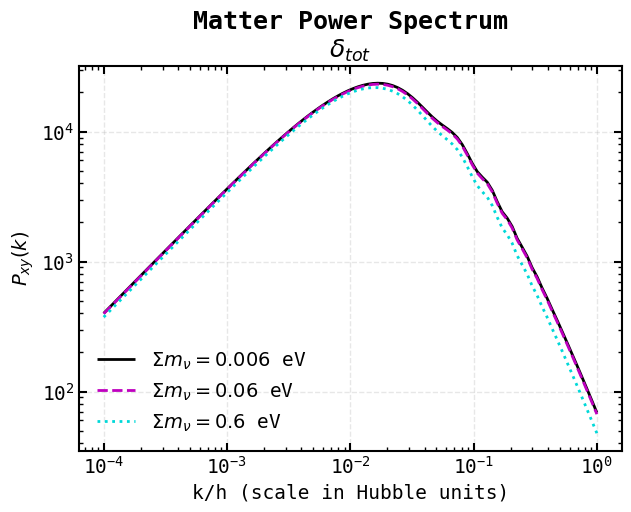

In [25]:
kz, Pk = np.loadtxt("CAMB_Pk_fiducial.dat", usecols=(0, 1), unpack=True)
kz_mNu, Pk_mNu = np.loadtxt("CAMB_Pk_massiveNu.dat", usecols=(0, 1), unpack=True)
kz_lNu, Pk_lNu = np.loadtxt("CAMB_Pk_lightNu.dat", usecols=(0, 1), unpack=True)


plt.plot(kz_lNu, Pk_lNu, label=r"$\Sigma m_{\nu}=0.006$ eV")
plt.plot(kz, Pk, label=r"$\Sigma m_{\nu}=0.06$ eV")
plt.plot(kz_mNu, Pk_mNu, label=r"$\Sigma m_{\nu}=0.6$ eV")
plt.legend()
plt.title("Matter Power Spectrum\n" + r"$\delta_{tot}$")
plt.xlabel("k/h (scale in Hubble units)")
plt.ylabel(r"$P_{xy}(k)$")
plt.semilogy()
plt.semilogx()
plt.show()

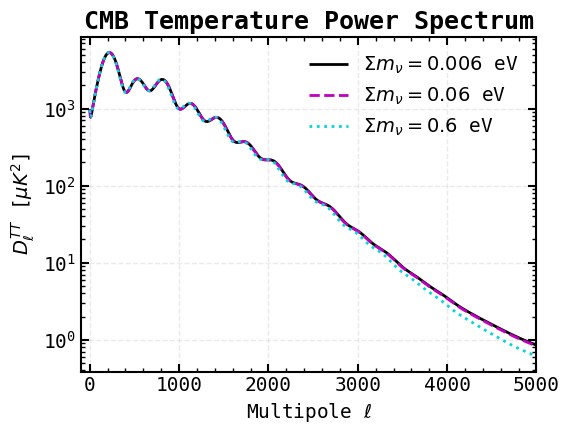

In [34]:
# ============================================================
# 1.2  Read and plot the temperature spectrum
# ============================================================


lell, lDlTT = np.loadtxt("CAMB_scalCls_lightNu.dat", usecols=(0, 1), unpack=True)
ell, DlTT = np.loadtxt("CAMB_scalCls_fiducial.dat", usecols=(0, 1), unpack=True)
ell_mNu, DlTT_mNu = np.loadtxt("CAMB_scalCls_massiveNu.dat", usecols=(0, 1), unpack=True)

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(lell[2:], lDlTT[2:], label=r"$\Sigma m_{\nu}=0.006$ eV")
ax.plot(ell[2:], DlTT[2:], label=r"$\Sigma m_{\nu}=0.06$ eV")
ax.plot(ell_mNu[2:], DlTT_mNu[2:], label=r"$\Sigma m_{\nu}=0.6$ eV")

ax.set_xlim(-100, 5000)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
ax.set_title("CMB Temperature Power Spectrum")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.semilogy()
plt.show()
